<a href="https://colab.research.google.com/github/rezailyaspratama26/rezaillyaspratama/blob/main/Notebook_Analisis_KPI_Pemasaran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook_Analisis_KPI_Pemasaran
Temuan kunci dan rekomendasi strategis untuk optimasi kinerja pemasaran secara keseluruhan.


**Reasoning**:
Synthesize the findings from previous subtasks into a summary of key takeaways and formulate strategic recommendations based on those findings.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tampilkan semua kolom
pd.set_option('display.max_columns', None)

# Load dataset
# Pastikan file 'Marketing.csv' berada di lokasi yang benar
try:
    df = pd.read_csv('/content/Marketing.csv')
    print("Dataset berhasil dimuat.")
    display(df.head())
except FileNotFoundError:
    print("Error: File 'Marketing.csv' tidak ditemukan. Pastikan path file sudah benar.")
    # Buat DataFrame kosong atau tangani error sesuai kebutuhan
    df = pd.DataFrame()

Dataset berhasil dimuat.


,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981.0
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962.0
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981.0
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114.0
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490.0


**Insight dari Data Loading:**
Setelah data berhasil dimuat, kita melihat beberapa baris pertama (`df.head()`) untuk mendapatkan gambaran awal tentang struktur data, nama kolom, dan tipe data kasar. Ini membantu kita memahami variabel apa saja yang tersedia untuk analisis.

---

## 2. 🔍 Data Overview & Informasi Awal

In [79]:
if not df.empty:
    print("Informasi Dataset:")
    df.info()

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicated Rows:")
    print(df.duplicated().sum())
else:
    print("DataFrame kosong, tidak dapat menampilkan informasi awal.")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             308 non-null    int64  
 1   c_date         308 non-null    object 
 2   campaign_name  308 non-null    object 
 3   category       308 non-null    object 
 4   campaign_id    308 non-null    int64  
 5   impressions    308 non-null    int64  
 6   mark_spent     308 non-null    float64
 7   clicks         308 non-null    int64  
 8   leads          308 non-null    int64  
 9   orders         308 non-null    int64  
 10  revenue        308 non-null    float64
dtypes: float64(2), int64(6), object(3)
memory usage: 26.6+ KB

Missing Values:
id               0
c_date           0
campaign_name    0
category         0
campaign_id      0
impressions      0
mark_spent       0
clicks           0
leads            0
orders           0
revenue          0
dtype: int64

D

**Insight dari Data Overview:**
- `df.info()` memberikan ringkasan tentang DataFrame, termasuk jumlah baris (entries), jumlah kolom, nama kolom, jumlah nilai non-null per kolom, dan tipe data (Dtype) dari setiap kolom. Ini penting untuk mengidentifikasi kolom mana yang memiliki missing values atau tipe data yang perlu diubah.
- `df.isnull().sum()` secara spesifik menghitung jumlah missing values (NaN) di setiap kolom. Output menunjukkan tidak ada missing values di dataset awal ini.
- `df.duplicated().sum()` memeriksa apakah ada baris yang persis sama (duplikat) dalam dataset. Output menunjukkan tidak ada baris duplikat.

---

## 3. 📊 Statistik Deskriptif

In [80]:
if not df.empty:
    print("Statistik Deskriptif:")
    display(df.describe(include='all'))
else:
    print("DataFrame kosong, tidak dapat menampilkan statistik deskriptif.")

Statistik Deskriptif:


,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
count,308.000000,308,308,308,3.080000e+02,3.080000e+02,308.000000,308.000000,308.000000,308.000000,3.080000e+02
unique,NaN,28,11,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2021-02-01,facebook_tier1,social,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,11,28,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,154.500000,NaN,NaN,NaN,9.605628e+06,5.122475e+06,99321.038377,9739.996753,212.918831,26.113636,1.392512e+05
std,89.056162,NaN,NaN,NaN,2.543040e+07,2.631134e+07,144008.011181,12157.476244,300.459978,42.741288,2.763031e+05
min,1.000000,NaN,NaN,NaN,1.093400e+04,6.670000e+02,169.750000,20.000000,0.000000,0.000000,0.000000e+00
25%,77.750000,NaN,NaN,NaN,1.278230e+05,1.479568e+05,9465.195000,1347.250000,20.750000,3.000000,8.580000e+03
50%,154.500000,NaN,NaN,NaN,3.747540e+05,6.028100e+05,36765.150000,4349.500000,84.000000,9.000000,3.891700e+04
75%,231.250000,NaN,NaN,NaN,4.387490e+06,3.254450e+06,129372.250000,13499.250000,270.500000,29.250000,1.370492e+05


**Insight dari Statistik Deskriptif:**
- `df.describe(include='all')` memberikan ringkasan statistik untuk kolom numerik dan kategorikal.
- Untuk kolom numerik (`impressions`, `mark_spent`, `clicks`, `leads`, `orders`, `revenue`), kita bisa melihat rata-rata (mean), standar deviasi (std), nilai minimum (min), maksimum (max), dan kuartil (25%, 50%, 75%). Ini memberikan gambaran tentang sebaran dan rentang nilai pada setiap metrik. Perhatikan nilai mean dan max yang jauh berbeda pada beberapa kolom (misalnya `impressions`, `mark_spent`, `revenue`), ini mengindikasikan adanya nilai outlier atau distribusi yang miring.
- Untuk kolom kategorikal (`c_date`, `campaign_name`, `category`), kita bisa melihat jumlah nilai unik (unique), nilai yang paling sering muncul (top), dan frekuensinya (freq). Ini membantu memahami variasi dalam data kategorikal. Terlihat ada 28 tanggal unik, 11 nama campaign unik, dan 4 kategori unik.

---

## 4. 🧼 Data Cleaning

In [81]:
if not df.empty:
    # Hapus duplikat jika ada (meskipun di cek awal tidak ada, ini praktik baik)
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    rows_after_dropping = df.shape[0]
    if initial_rows > rows_after_dropping:
        print(f"Duplikat dihapus: {initial_rows - rows_after_dropping} baris.")
    else:
        print("Tidak ada duplikat untuk dihapus.")

    # Convert tanggal jika perlu
    # Berdasarkan df.info(), 'c_date' bertipe object. Perlu diubah ke datetime.
    df['c_date'] = pd.to_datetime(df['c_date'])
    print("\nKolom 'c_date' berhasil diubah menjadi tipe datetime.")
    print(df['c_date'].info())


    # Tangani missing values jika perlu (berdasarkan cek awal, tidak ada missing values)
    # Jika ada missing values, strategi penanganan bisa berupa:
    # df.fillna(method='ffill', inplace=True) # Mengisi dengan nilai sebelumnya
    # df.fillna(df.mean(), inplace=True) # Mengisi dengan rata-rata (untuk numerik)
    # df.dropna(inplace=True) # Menghapus baris dengan missing values
    print("\nTidak ada missing values yang perlu ditangani pada tahap ini (selain yang mungkin muncul setelah perhitungan KPI).")

else:
    print("DataFrame kosong, tidak dapat melakukan data cleaning.")

Tidak ada duplikat untuk dihapus.

Kolom 'c_date' berhasil diubah menjadi tipe datetime.
<class 'pandas.core.series.Series'>
RangeIndex: 308 entries, 0 to 307
Series name: c_date
Non-Null Count  Dtype         
--------------  -----         
308 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.5 KB
None

Tidak ada missing values yang perlu ditangani pada tahap ini (selain yang mungkin muncul setelah perhitungan KPI).


**Insight dan Rekomendasi dari Data Cleaning:**
- Penghapusan duplikat adalah langkah penting untuk memastikan setiap observasi bersifat unik dan tidak bias.
- Konversi kolom tanggal ke tipe data datetime sangat krusial untuk analisis berbasis waktu (tren harian, mingguan, bulanan, dll.). Tanpa konversi ini, operasi pengurutan atau pengelompokan berdasarkan waktu tidak akan akurat.
- Karena tidak ada missing values di data awal, kita tidak perlu menerapkan strategi pengisian atau penghapusan missing values di sini. Namun, penting untuk bersiap menangani missing values yang mungkin muncul nanti, terutama setelah perhitungan KPI (misalnya, pembagian dengan nol).

---

## 5. 📈 Visualisasi Awal & Korelasi Variabel

Visualisasi Korelasi antar variabel numerik:


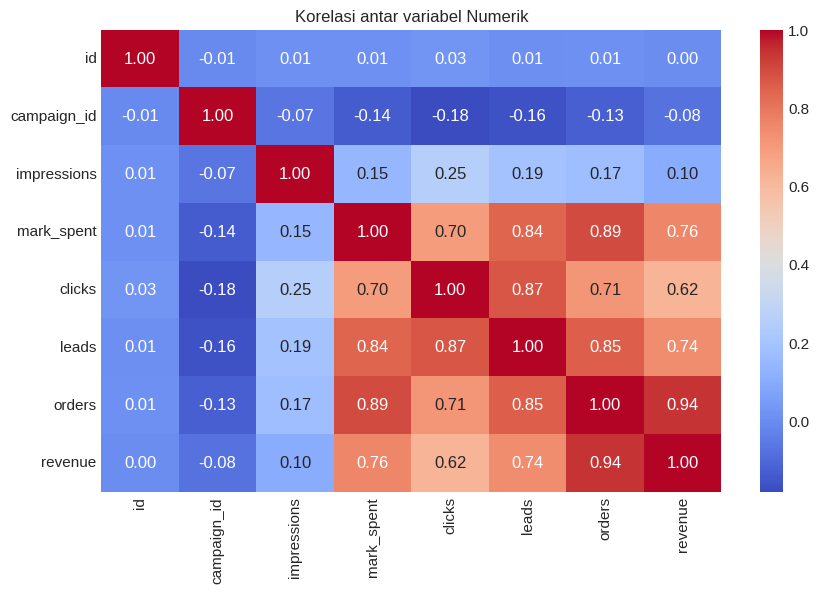

In [82]:
if not df.empty:
    print("Visualisasi Korelasi antar variabel numerik:")
    plt.figure(figsize=(10, 6))
    # Pilih hanya kolom numerik untuk korelasi
    df_numeric = df.select_dtypes(include=np.number)
    sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Korelasi antar variabel Numerik')
    plt.show()
else:
    print("DataFrame kosong, tidak dapat menampilkan visualisasi korelasi.")

**Insight dan Rekomendasi dari Visualisasi Korelasi Awal:**
- Heatmap korelasi menunjukkan hubungan linier antara pasangan variabel numerik. Nilai mendekati 1 (positif) atau -1 (negatif) menunjukkan korelasi kuat, sementara nilai mendekati 0 menunjukkan korelasi lemah.
- Amati korelasi antara metrik pengeluaran (`mark_spent`) dan metrik hasil (`impressions`, `clicks`, `leads`, `orders`, `revenue`). Korelasi positif yang kuat antara pengeluaran dan hasil ini wajar, karena campaign dengan anggaran lebih besar cenderung menghasilkan volume yang lebih tinggi.
- Perhatikan juga korelasi antar metrik hasil (misalnya, `clicks` dengan `leads`, `leads` dengan `orders`, `orders` dengan `revenue`). Korelasi positif yang kuat di sini menunjukkan alur konversi yang sehat: lebih banyak klik mengarah ke lebih banyak leads, yang mengarah ke lebih banyak pesanan dan revenue.
- **Rekomendasi:** Korelasi ini adalah gambaran awal. Korelasi tidak selalu berarti kausalitas. Analisis lebih lanjut diperlukan untuk memahami dinamika sebenarnya. Misalnya, campaign dengan korelasi pengeluaran-hasil yang rendah mungkin tidak efisien.

---

## 6. 📐 Perhitungan KPI Penting & Penanganan Nilai Inf

In [83]:
if not df.empty:
    # Tambahkan kolom KPI
    # Gunakan penanganan ZeroDivisionError dengan numpy.errstate
    with np.errstate(divide='ignore', invalid='ignore'):
        df['CTR'] = df['clicks'] / df['impressions']  # Click-Through Rate
        df['CPC'] = df['mark_spent'] / df['clicks']   # Cost Per Click
        df['CPR'] = df['mark_spent'] / df['leads']    # Cost Per Lead
        # Tambahkan KPI penting lainnya jika relevan, misal:
        df['CPO'] = df['mark_spent'] / df['orders']   # Cost Per Order
        df['ROAS'] = (df['revenue'] / df['mark_spent']) * 100 # Return on Ad Spend (%)


    # Mengganti nilai inf dan NaN yang muncul akibat pembagian dengan nol atau nilai tidak valid
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    print("KPI berhasil dihitung.")

    # Cek missing values setelah penanganan inf
    print("\nMissing Values setelah perhitungan KPI dan penanganan Inf/NaN:")
    print(df[['CTR', 'CPC', 'CPR', 'CPO', 'ROAS']].isnull().sum())

    # Tampilkan ringkasan statistik dari kolom KPI yang baru
    print("\nRingkasan Statistik KPI:")
    display(df[['CTR', 'CPC', 'CPR', 'CPO', 'ROAS']].describe())

    # Tampilkan beberapa baris sebagai contoh
    print("\nContoh beberapa baris dengan KPI:")
    display(df[['campaign_name', 'impressions', 'clicks', 'leads', 'orders', 'revenue', 'mark_spent', 'CTR', 'CPC', 'CPR', 'CPO', 'ROAS']].head())

else:
    print("DataFrame kosong, tidak dapat menghitung KPI.")

KPI berhasil dihitung.

Missing Values setelah perhitungan KPI dan penanganan Inf/NaN:
CTR      0
CPC      0
CPR      4
CPO     19
ROAS     0
dtype: int64

Ringkasan Statistik KPI:


,CTR,CPC,CPR,CPO,ROAS
count,308.000000,308.000000,304.000000,289.000000,308.000000
mean,0.009592,11.270120,548.058663,4220.730401,140.761155
std,0.008222,8.181154,325.906180,1954.856697,121.770553
min,0.000079,0.043053,17.763137,885.750000,0.000000
25%,0.005000,6.138858,362.508333,2963.285714,68.115856
50%,0.006916,9.713270,497.781613,3788.400000,110.557847
75%,0.011083,15.175455,637.426959,5130.936364,176.021994
max,0.033556,54.772955,1694.859155,10104.900000,659.398731



Contoh beberapa baris dengan KPI:


,campaign_name,impressions,clicks,leads,orders,revenue,mark_spent,CTR,CPC,CPR,CPO,ROAS
0,facebook_tier1,148263,1210,13,1,4981.0,7307.37,0.008161,6.039149,562.105385,7307.37,68.164059
1,facebOOK_tier2,220688,1640,48,3,14962.0,16300.20,0.007431,9.939146,339.587500,5433.40,91.790285
2,google_hot,22850,457,9,1,7981.0,5221.60,0.020000,11.425821,580.177778,5221.60,152.845871
3,google_wide,147038,1196,24,1,2114.0,6037.00,0.008134,5.047659,251.541667,6037.00,35.017393
4,youtube_blogger,225800,2258,49,10,84490.0,29962.20,0.010000,13.269353,611.473469,2996.22,281.988639


**Insight dan Rekomendasi dari Perhitungan KPI:**
- KPI seperti CTR, CPC, CPR, CPO, dan ROAS adalah metrik kunci untuk mengevaluasi efisiensi dan efektivitas campaign pemasaran.
- **Penanganan Nilai Inf/NaN:** Munculnya missing values (NaN) di kolom KPI (terutama CPR dan CPO) menandakan adanya campaign atau data point di mana tidak terjadi leads atau orders (pembagi bernilai nol). Ini adalah insight penting: ada campaign yang tidak berhasil menghasilkan konversi pada tahap leads atau orders.
- **Ringkasan Statistik KPI:** Melihat statistik deskriptif KPI memberikan gambaran tentang rata-rata performa, sebaran (std), serta nilai minimum dan maksimum. Rentang nilai yang lebar pada beberapa KPI (misalnya CPR atau CPO) menunjukkan variasi performa yang signifikan antar campaign atau hari.
- **Rekomendasi:** Missing values pada KPI konversi (CPR, CPO) perlu diinvestigasi lebih lanjut. Campaign yang menghasilkan NaN di sini mungkin perlu dihentikan atau dirombak total jika tujuan utamanya adalah leads atau sales. Analisis selanjutnya akan fokus pada perbandingan KPI ini antar campaign dan kategori.

---

## 7. 📊 Analisis Distribusi Variabel Kunci (dengan KPI)

Visualisasi Distribusi Variabel Kunci (termasuk KPI):


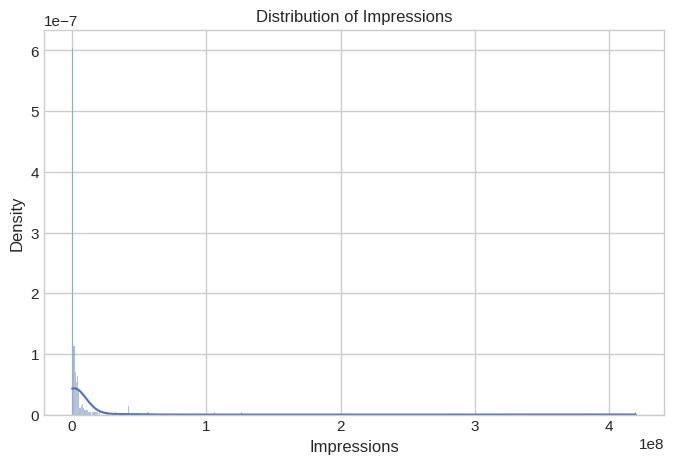

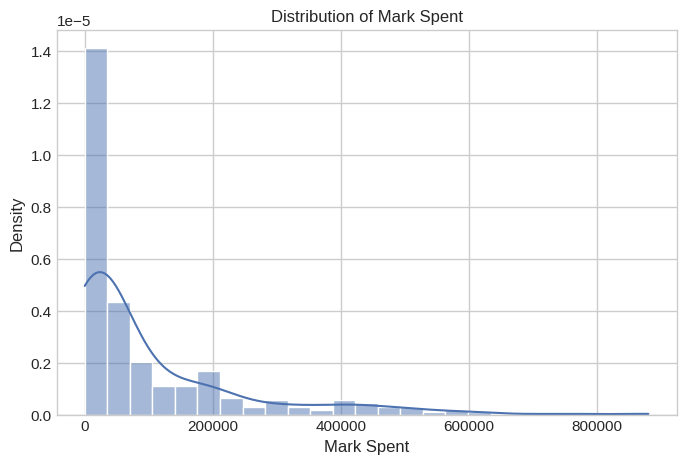

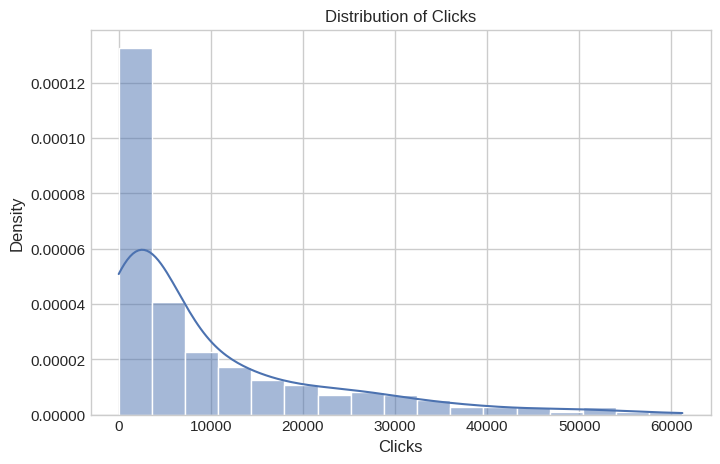

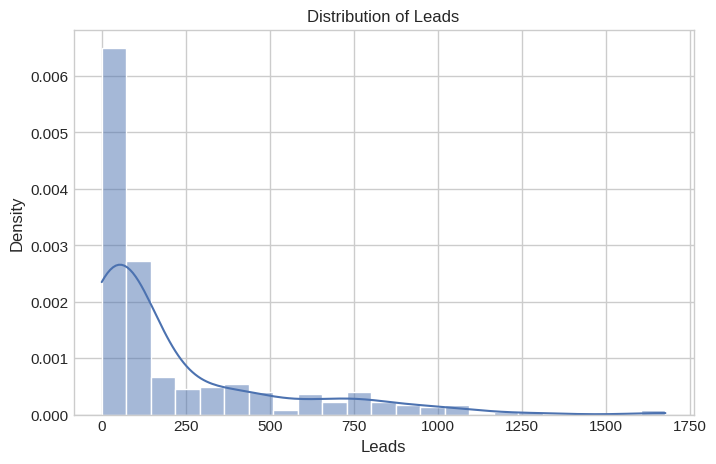

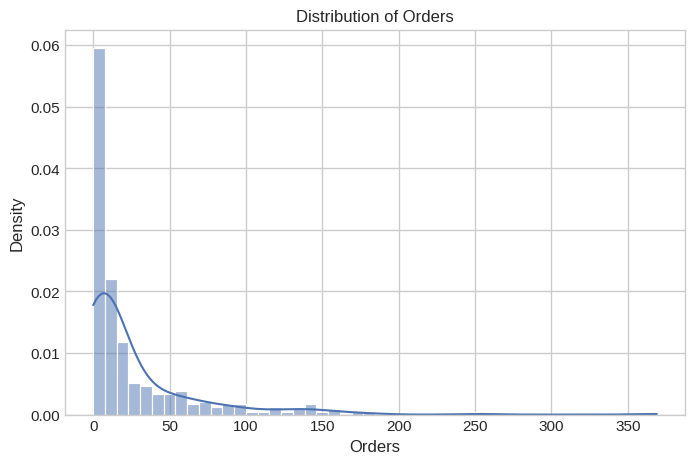

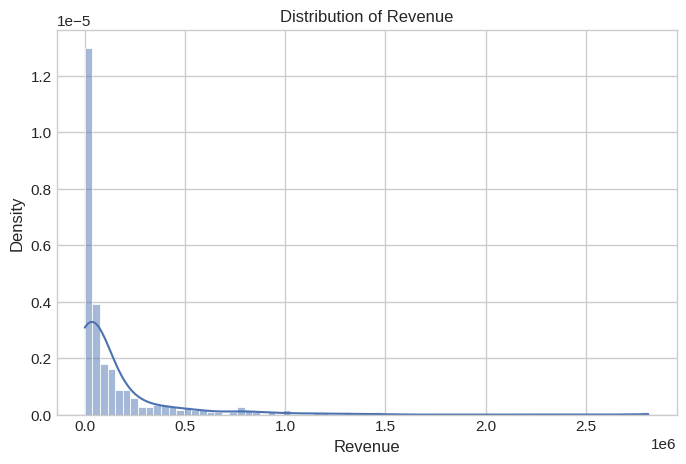

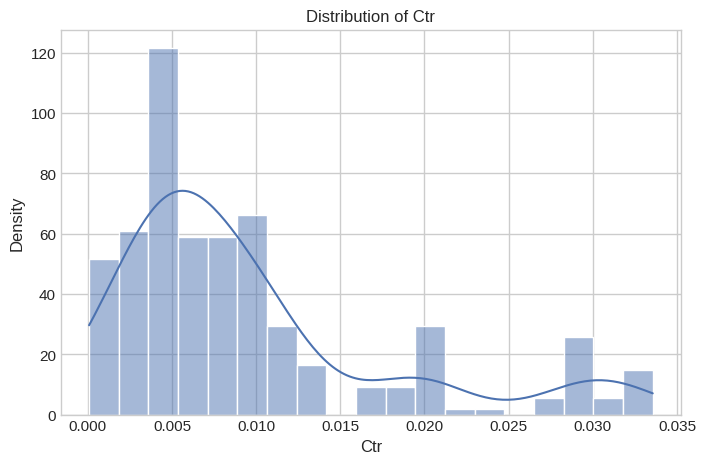

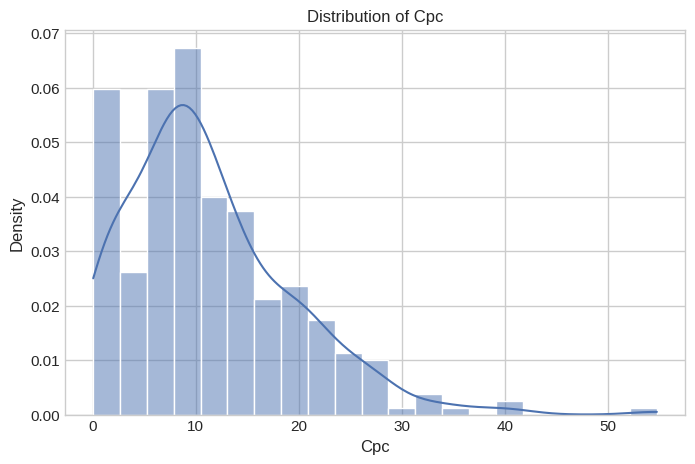

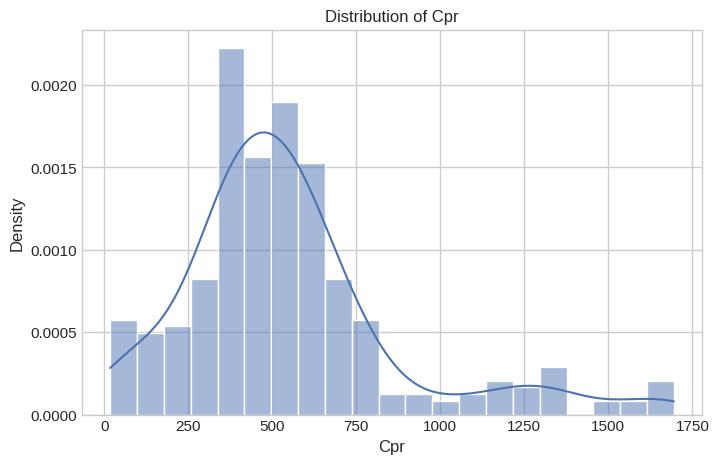

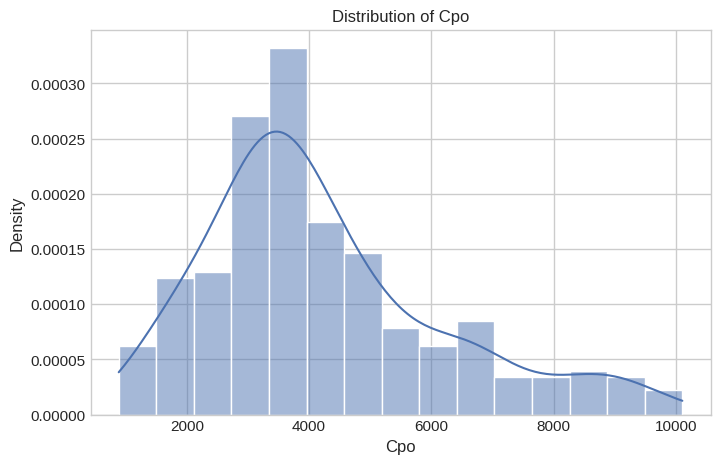

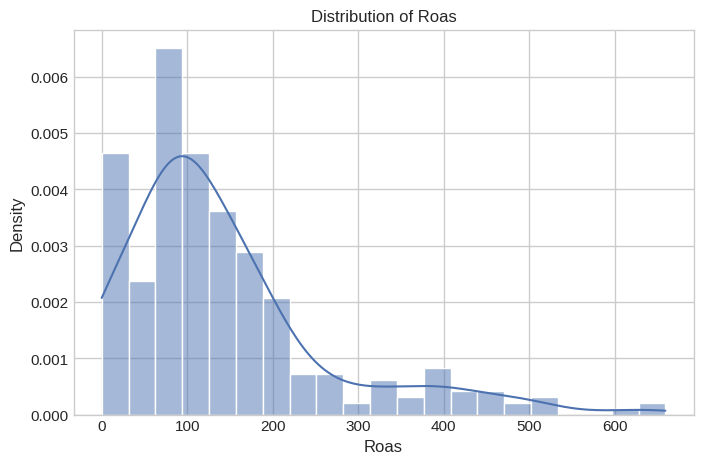

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if not df.empty:
    print("Visualisasi Distribusi Variabel Kunci (termasuk KPI):")
    columns_to_visualize_with_kpi = ['impressions', 'mark_spent', 'clicks', 'leads', 'orders', 'revenue', 'CTR', 'CPC', 'CPR', 'CPO', 'ROAS']

    for col in columns_to_visualize_with_kpi:
        # Perbaiki pengecekan tipe data untuk menghindari DeprecationWarning
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]): # Cek tipe data numerik
            plt.figure(figsize=(8, 5))
            sns.histplot(data=df, x=col, kde=True, stat="density")
            plt.title(f'Distribution of {col.replace("_", " ").title()}')
            plt.xlabel(col.replace("_", " ").title())
            plt.ylabel('Density')
            plt.show()
        elif col in df.columns and pd.api.types.is_datetime64_any_dtype(df[col]): # Cek tipe data datetime
             # Visualisasi distribusi datetime mungkin tidak umum, bisa disesuaikan
             # Untuk saat ini, kita lewati visualisasi histogram untuk datetime
             print(f"Kolom '{col}' bertipe datetime, visualisasi distribusi histogram dilewati.")
        elif col in df.columns:
             print(f"Kolom '{col}' bukan numerik atau datetime, dilewati untuk visualisasi distribusi.")
        else:
             print(f"Kolom '{col}' tidak ditemukan, dilewati untuk visualisasi distribusi.")
else:
    print("DataFrame kosong, tidak dapat menampilkan visualisasi distribusi.")

**Insight dari Analisis Distribusi Variabel Kunci (dengan KPI):**
- Distribusi metrik dasar (`impressions`, `mark_spent`, `clicks`, `leads`, `orders`, `revenue`) sebagian besar miring ke kanan (right-skewed). Ini mengkonfirmasi temuan awal dari statistik deskriptif dan menunjukkan bahwa sebagian besar campaign atau hari memiliki volume/pengeluaran/hasil yang relatif rendah, sementara ada beberapa yang memiliki nilai sangat tinggi. Ini penting untuk dipahami karena rata-rata bisa sangat dipengaruhi oleh outlier ini.
- Distribusi KPI (`CTR`, `CPC`, `CPR`, `CPO`, `ROAS`) juga menunjukkan variasi. Beberapa KPI mungkin terlihat lebih merata distribusinya, sementara yang lain (terutama CPO dan CPR dengan nilai NaN yang banyak) mungkin memiliki distribusi yang sangat terkonsentrasi pada nilai tertentu atau memiliki ekor panjang.
- **Rekomendasi:** Memahami distribusi membantu kita memilih metode analisis yang tepat (misalnya, menggunakan median selain mean untuk data yang sangat miring) dan mengidentifikasi potensi outlier yang mungkin memerlukan investigasi lebih lanjut.

---

## 8. 📈 Visualisasi KPI per Campaign (dengan KPI Lengkap)

Visualisasi KPI Rata-rata per Campaign:


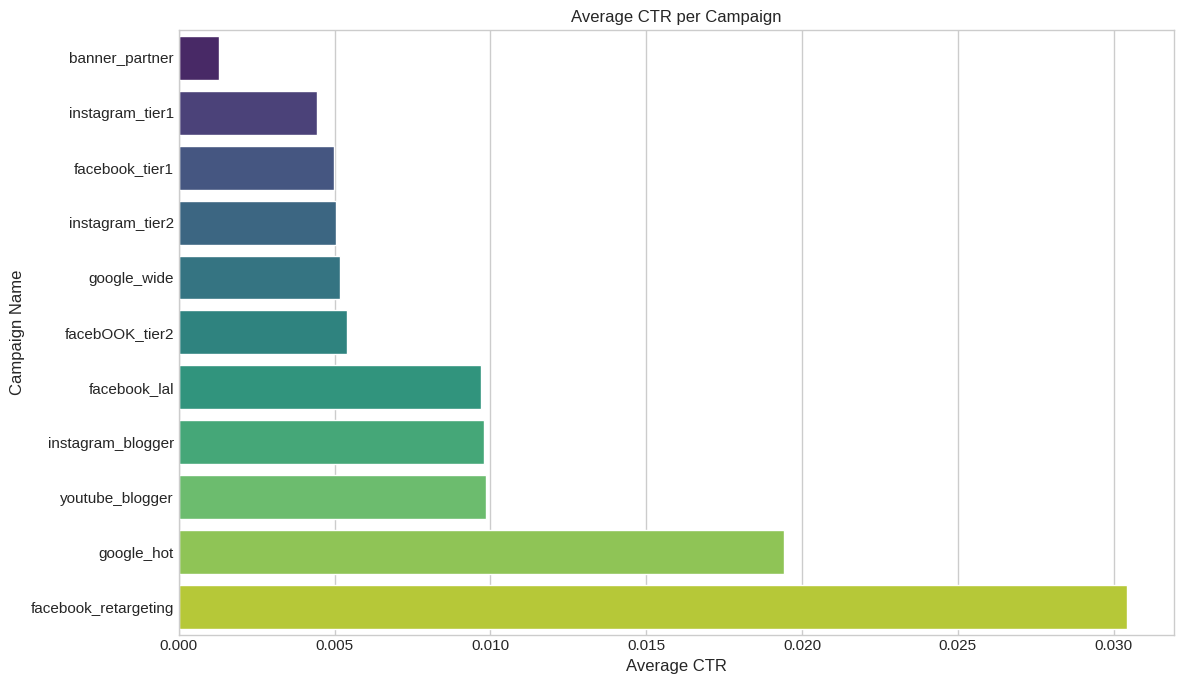

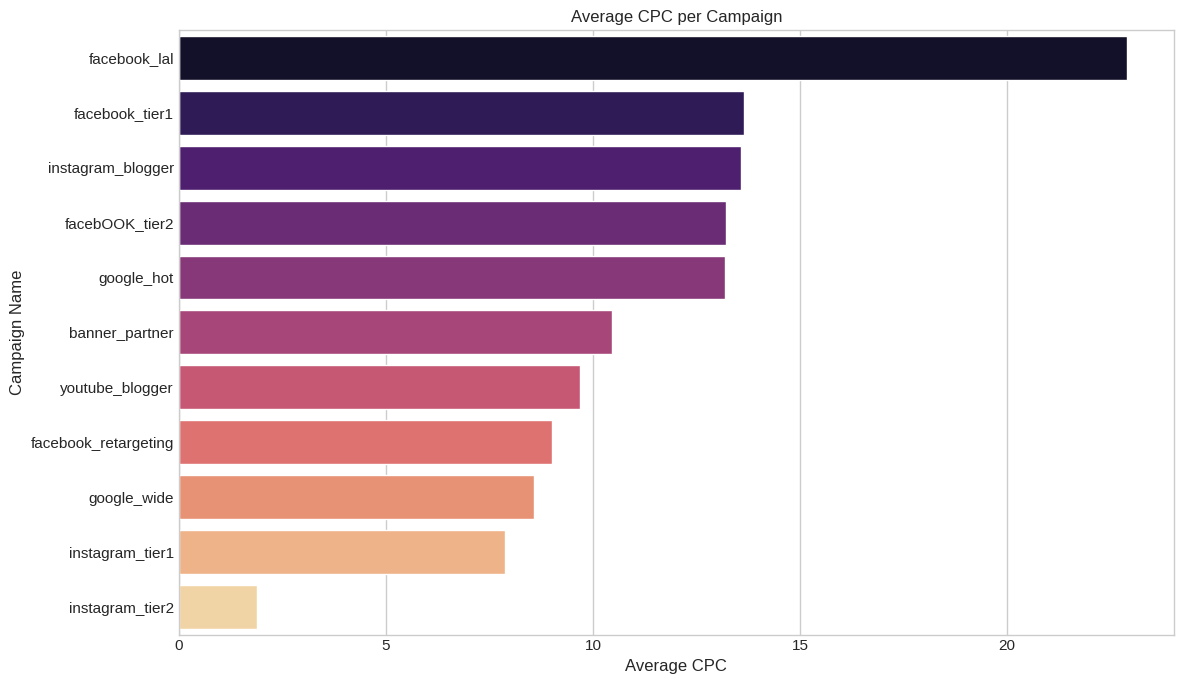

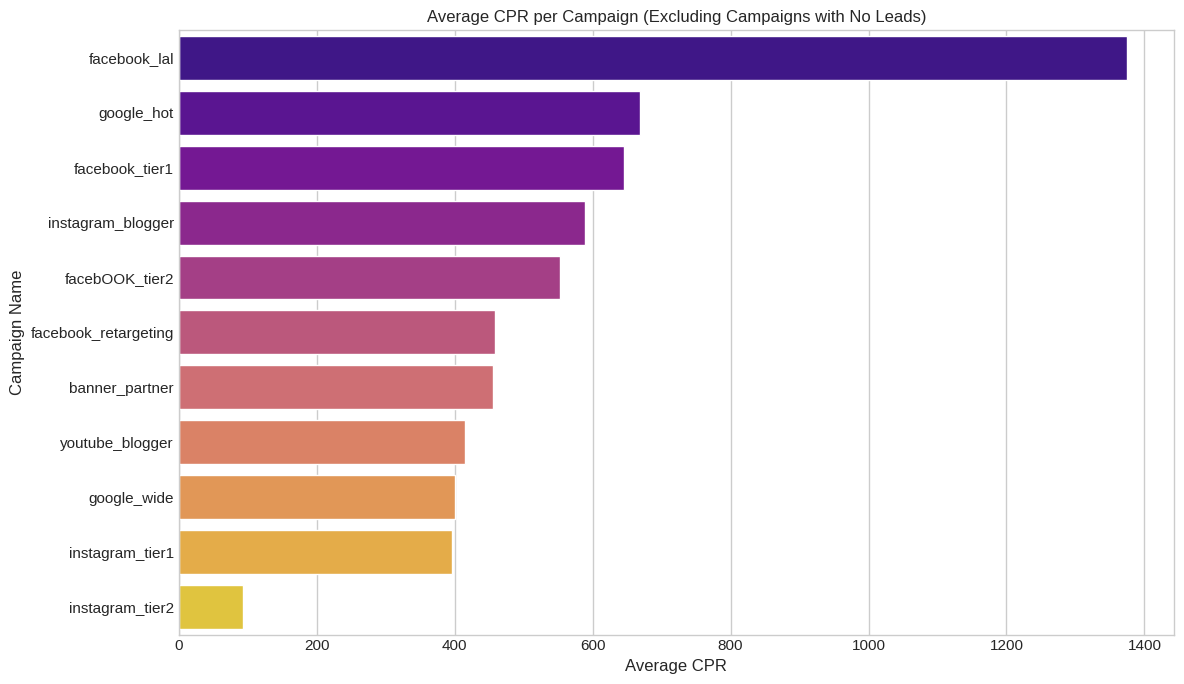

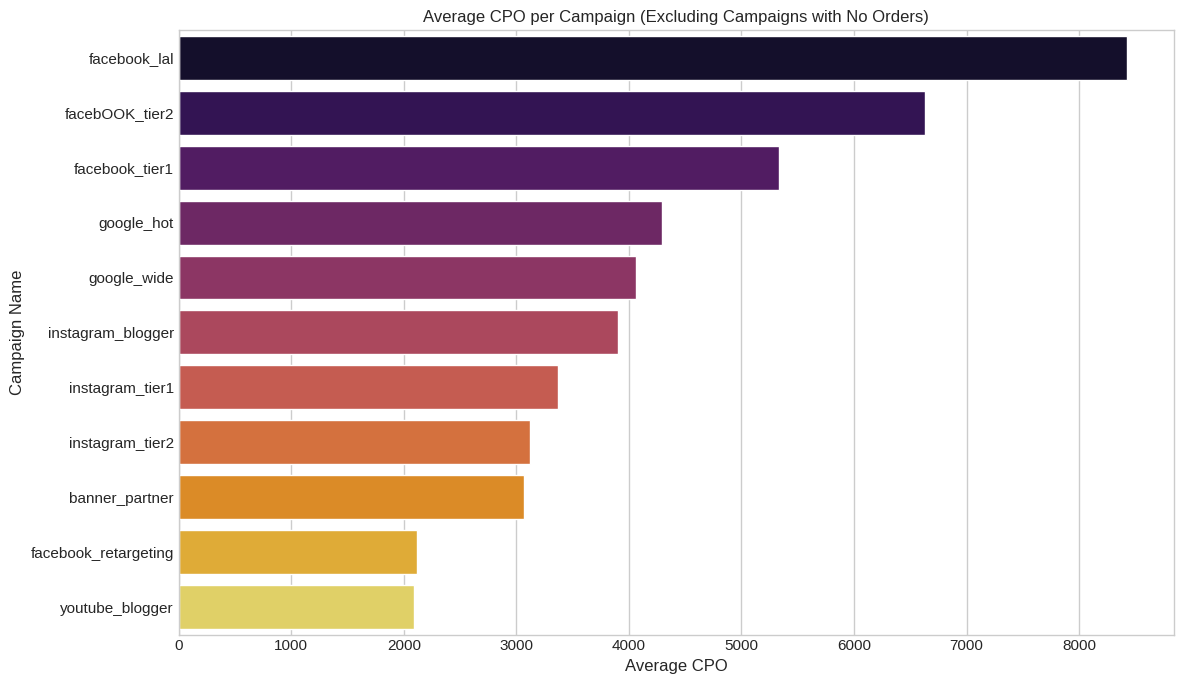

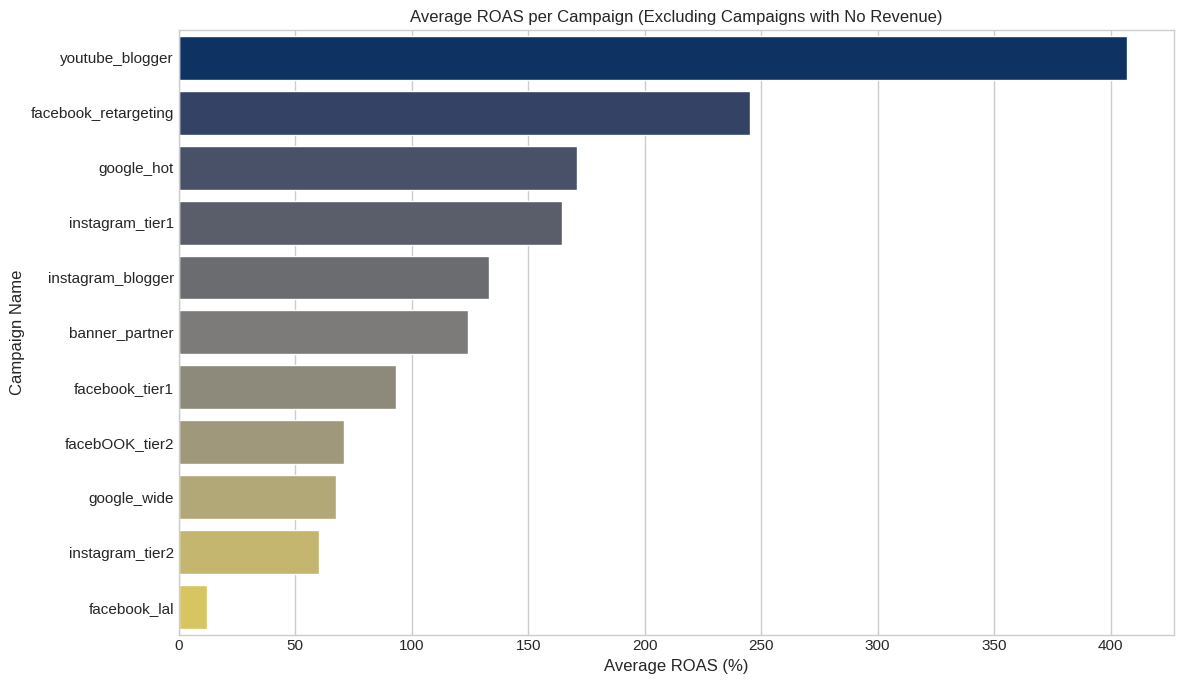

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if not df.empty:
    print("Visualisasi KPI Rata-rata per Campaign:")

    # Hitung rata-rata KPI per campaign
    campaign_kpi_avg = df.groupby('campaign_name')[['CTR', 'CPC', 'CPR', 'CPO', 'ROAS']].mean().reset_index()

    # Visualisasi CTR per Campaign - Perbaiki FutureWarning
    plt.figure(figsize=(12, 7))
    sns.barplot(data=campaign_kpi_avg.sort_values('CTR'), x='CTR', y='campaign_name', palette='viridis', hue='campaign_name', legend=False)
    plt.title('Average CTR per Campaign')
    plt.xlabel('Average CTR')
    plt.ylabel('Campaign Name')
    plt.tight_layout()
    plt.show()

    # Visualisasi CPC per Campaign - Perbaiki FutureWarning
    plt.figure(figsize=(12, 7))
    sns.barplot(data=campaign_kpi_avg.sort_values('CPC', ascending=False), x='CPC', y='campaign_name', palette='magma', hue='campaign_name', legend=False)
    plt.title('Average CPC per Campaign')
    plt.xlabel('Average CPC')
    plt.ylabel('Campaign Name')
    plt.tight_layout()
    plt.show()

    # Visualisasi CPR per Campaign (abaikan NaN untuk visualisasi bar) - Perbaiki FutureWarning
    plt.figure(figsize=(12, 7))
    sns.barplot(data=campaign_kpi_avg.dropna(subset=['CPR']).sort_values('CPR', ascending=False), x='CPR', y='campaign_name', palette='plasma', hue='campaign_name', legend=False)
    plt.title('Average CPR per Campaign (Excluding Campaigns with No Leads)')
    plt.xlabel('Average CPR')
    plt.ylabel('Campaign Name')
    plt.tight_layout()
    plt.show()

    # Visualisasi CPO per Campaign (abaikan NaN untuk visualisasi bar) - Perbaiki FutureWarning
    plt.figure(figsize=(12, 7))
    sns.barplot(data=campaign_kpi_avg.dropna(subset=['CPO']).sort_values('CPO', ascending=False), x='CPO', y='campaign_name', palette='inferno', hue='campaign_name', legend=False)
    plt.title('Average CPO per Campaign (Excluding Campaigns with No Orders)')
    plt.xlabel('Average CPO')
    plt.ylabel('Campaign Name')
    plt.tight_layout()
    plt.show()

    # Visualisasi ROAS per Campaign (abaikan NaN untuk visualisasi bar) - Perbaiki FutureWarning
    plt.figure(figsize=(12, 7))
    sns.barplot(data=campaign_kpi_avg.dropna(subset=['ROAS']).sort_values('ROAS', ascending=False), x='ROAS', y='campaign_name', palette='cividis', hue='campaign_name', legend=False)
    plt.title('Average ROAS per Campaign (Excluding Campaigns with No Revenue)')
    plt.xlabel('Average ROAS (%)')
    plt.ylabel('Campaign Name')
    plt.tight_layout()
    plt.show()

else:
    print("DataFrame kosong, tidak dapat menampilkan visualisasi KPI per campaign.")

**Insight dan Rekomendasi dari Visualisasi KPI per Campaign:**
- Visualisasi ini memungkinkan perbandingan langsung performa rata-rata KPI antar campaign.
- Campaign dengan CTR tinggi berhasil menarik perhatian audiens. Campaign dengan CPC rendah efisien dalam menghasilkan klik. Campaign dengan CPR rendah efisien dalam menghasilkan leads. Campaign dengan CPO rendah efisien dalam menghasilkan orders. Campaign dengan ROAS tinggi memberikan pengembalian investasi iklan yang baik.
- Perhatikan campaign mana yang menonjol di setiap metrik. Campaign 'facebook_retargeting' memiliki CTR tertinggi, 'instagram_tier2' memiliki CPC dan CPR terendah. 'youtube_blogger' memiliki ROAS tertinggi.
- **Rekomendasi:** Campaign yang berkinerja baik pada KPI kunci (sesuai tujuan bisnis) harus dipertimbangkan untuk peningkatan anggaran atau studi kasus. Campaign yang berkinerja buruk perlu diinvestigasi lebih lanjut (penargetan, kreatif, landing page) atau dihentikan. Adanya campaign dengan NaN pada CPR, CPO, atau ROAS menandakan campaign tersebut tidak efektif dalam menghasilkan konversi di tahap tersebut.

---

## 9. 📊 Analisis Performa per Kategori Campaign (dengan KPI Lengkap)

In [86]:
if not df.empty:
    print("Rata-rata KPI dan Revenue per Kategori Campaign:")
    # Group by category and calculate the mean of relevant columns
    category_performance = df.groupby('category')[['CTR', 'CPC', 'CPR', 'CPO', 'ROAS', 'revenue']].mean().reset_index()

    # Print the resulting DataFrame
    display(category_performance)

    print("\n--- Insight dan Rekomendasi per Kategori Campaign ---")

    # Analisis berdasarkan tabel rata-rata per kategori
    print("\nInsight:")
    print(f"- Kategori 'influencer' memiliki rata-rata revenue tertinggi ({category_performance.loc[category_performance['category'] == 'influencer', 'revenue'].values[0]:,.2f}), meskipun CPC dan CPR-nya bukan yang terendah.")
    print(f"- Kategori 'media' memiliki rata-rata CPR terendah ({category_performance.loc[category_performance['category'] == 'media', 'CPR'].values[0]:,.2f}) dan ROAS tertinggi ({category_performance.loc[category_performance['category'] == 'media', 'ROAS'].values[0]:,.2f}%), menunjukkan efisiensi biaya yang sangat baik dalam menghasilkan leads dan pengembalian investasi.")
    print(f"- Kategori 'search' memiliki rata-rata CTR tertinggi ({category_performance.loc[category_performance['category'] == 'search', 'CTR'].values[0]:.4f}), menandakan iklan mereka sangat menarik perhatian.")
    print("- Kategori 'social' memiliki rata-rata CPR dan CPO yang relatif tinggi, serta ROAS yang lebih rendah dibandingkan 'influencer' dan 'media'.")

    print("\nRekomendasi:")
    print("- **Kategori 'influencer' & 'media':** Alokasikan lebih banyak anggaran ke kategori ini karena ROI dan efisiensi lead/sales yang baik. Pelajari faktor kunci keberhasilan mereka.")
    print("- **Kategori 'search':** Manfaatkan CTR yang tinggi untuk mengoptimalkan alur konversi setelah klik (landing page, penawaran) agar menghasilkan leads dan sales yang lebih efisien (menurunkan CPR/CPO).")
    print("- **Kategori 'social':** Kategori ini memerlukan optimasi mendalam. Identifikasi campaign sosial mana yang berkinerja buruk dan lakukan A/B testing pada penargetan, kreatif, dan funnel konversi. Pertimbangkan realokasi anggaran dari campaign sosial yang sangat tidak efisien.")
    print("- Pertimbangkan untuk menetapkan target KPI spesifik per kategori berdasarkan performa historis ini dan tujuan bisnis ke depan.")

else:
    print("DataFrame kosong, tidak dapat menampilkan analisis per kategori campaign.")

Rata-rata KPI dan Revenue per Kategori Campaign:


,category,CTR,CPC,CPR,CPO,ROAS,revenue
0,influencer,0.009834,11.619038,501.980490,2995.661197,270.003927,377140.839286
1,media,0.001290,10.451950,456.060290,3071.594628,124.226054,219748.571429
2,search,0.012297,10.878875,534.135126,4177.314967,119.141372,66161.875000
3,social,0.009994,11.420590,584.254090,4877.793166,107.642676,70901.511905



--- Insight dan Rekomendasi per Kategori Campaign ---

Insight:
- Kategori 'influencer' memiliki rata-rata revenue tertinggi (377,140.84), meskipun CPC dan CPR-nya bukan yang terendah.
- Kategori 'media' memiliki rata-rata CPR terendah (456.06) dan ROAS tertinggi (124.23%), menunjukkan efisiensi biaya yang sangat baik dalam menghasilkan leads dan pengembalian investasi.
- Kategori 'search' memiliki rata-rata CTR tertinggi (0.0123), menandakan iklan mereka sangat menarik perhatian.
- Kategori 'social' memiliki rata-rata CPR dan CPO yang relatif tinggi, serta ROAS yang lebih rendah dibandingkan 'influencer' dan 'media'.

Rekomendasi:
- **Kategori 'influencer' & 'media':** Alokasikan lebih banyak anggaran ke kategori ini karena ROI dan efisiensi lead/sales yang baik. Pelajari faktor kunci keberhasilan mereka.
- **Kategori 'search':** Manfaatkan CTR yang tinggi untuk mengoptimalkan alur konversi setelah klik (landing page, penawaran) agar menghasilkan leads dan sales yang lebih efisien (m

---

## 10. 📈 Analisis Performa Campaign dari Waktu ke Waktu

Visualisasi Tren Harian KPI dan Revenue:


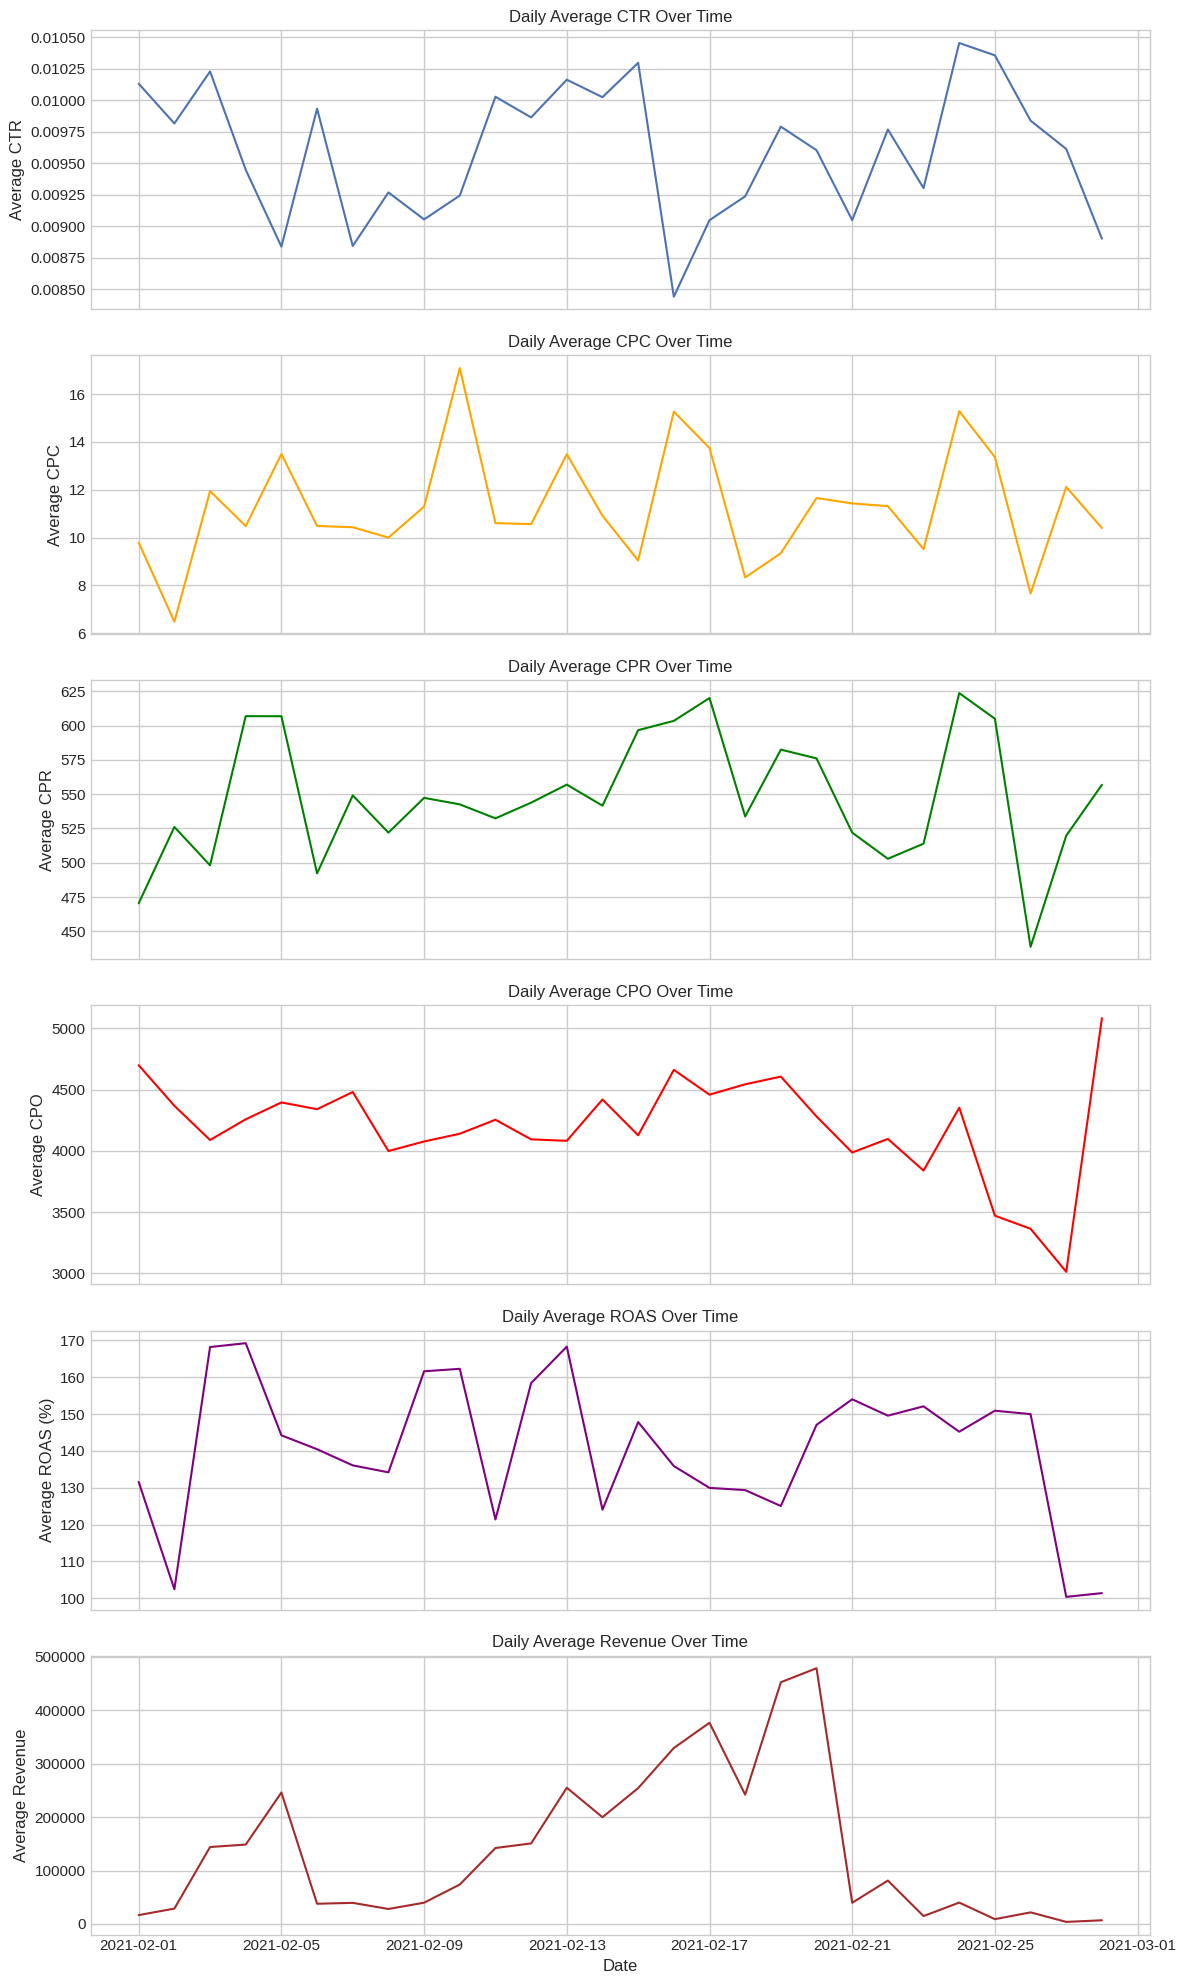

In [87]:
if not df.empty:
    print("Visualisasi Tren Harian KPI dan Revenue:")
    # Group by date and calculate the mean of the specified columns
    daily_performance = df.groupby('c_date')[['CTR', 'CPC', 'CPR', 'CPO', 'ROAS', 'revenue']].mean().reset_index()

    # Sort the daily_performance DataFrame by date (sudah dilakukan saat konversi datetime)
    daily_performance = daily_performance.sort_values(by='c_date')

    # Create line plots for 'CTR', 'CPC', 'CPR', 'CPO', 'ROAS', and 'revenue' over time
    fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 20), sharex=True)

    axes[0].plot(daily_performance['c_date'], daily_performance['CTR'])
    axes[0].set_title('Daily Average CTR Over Time')
    axes[0].set_ylabel('Average CTR')

    axes[1].plot(daily_performance['c_date'], daily_performance['CPC'], color='orange')
    axes[1].set_title('Daily Average CPC Over Time')
    axes[1].set_ylabel('Average CPC')

    axes[2].plot(daily_performance['c_date'], daily_performance['CPR'], color='green')
    axes[2].set_title('Daily Average CPR Over Time')
    axes[2].set_ylabel('Average CPR')

    axes[3].plot(daily_performance['c_date'], daily_performance['CPO'], color='red')
    axes[3].set_title('Daily Average CPO Over Time')
    axes[3].set_ylabel('Average CPO')

    axes[4].plot(daily_performance['c_date'], daily_performance['ROAS'], color='purple')
    axes[4].set_title('Daily Average ROAS Over Time')
    axes[4].set_ylabel('Average ROAS (%)')

    axes[5].plot(daily_performance['c_date'], daily_performance['revenue'], color='brown')
    axes[5].set_title('Daily Average Revenue Over Time')
    axes[5].set_ylabel('Average Revenue')
    axes[5].set_xlabel('Date')

    plt.tight_layout()
    plt.show()

else:
    print("DataFrame kosong, tidak dapat menampilkan analisis tren harian.")

**Insight dan Rekomendasi dari Analisis Tren Harian:**
- Visualisasi tren harian menunjukkan fluktuasi performa dari waktu ke waktu untuk semua metrik. Dalam periode data yang singkat (sekitar satu bulan), tidak terlihat tren naik atau turun jangka panjang yang jelas, namun ada variasi harian yang signifikan.
- Amati apakah ada pola harian atau mingguan dalam performa (misalnya, performa lebih baik di akhir pekan).
- Fluktuasi tajam pada metrik tertentu (terutama CPR, CPO, ROAS, dan Revenue) bisa disebabkan oleh campaign dengan volume besar yang berjalan di hari-hari tertentu atau faktor eksternal lainnya.
- **Rekomendasi:** Monitoring tren harian sangat penting untuk deteksi dini masalah performa atau peluang baru. Jika data mencakup periode yang lebih lama, analisis tren mingguan/bulanan akan lebih relevan untuk melihat perubahan performa jangka panjang. Identifikasi hari-hari dengan performa sangat baik atau sangat buruk untuk memahami faktor penyebabnya.

---

## 11. 🏆 Identifikasi Campaign Berkinerja Terbaik dan Terburuk

In [88]:
if not df.empty:
    print("Analisis Campaign Berkinerja Terbaik dan Terburuk:")

    # Define the list of required KPI columns
    kpi_columns = ['CTR', 'CPC', 'CPR', 'CPO', 'ROAS', 'revenue']

    # Check if all required KPI columns exist in the DataFrame
    if all(col in df.columns for col in kpi_columns):
        # Calculate average KPI and revenue for each campaign
        campaign_performance = df.groupby('campaign_name')[kpi_columns].mean().reset_index()

        # Sort by average revenue (descending)
        campaign_performance_by_revenue = campaign_performance.sort_values(by='revenue', ascending=False)

        # Sort by average ROAS (descending)
        campaign_performance_by_roas = campaign_performance.sort_values(by='ROAS', ascending=False)

        # Sort by average CPR (ascending) - lower CPR is better
        campaign_performance_by_cpr = campaign_performance.sort_values(by='CPR', ascending=True)

        # Sort by average CPO (ascending) - lower CPO is better
        campaign_performance_by_cpo = campaign_performance.sort_values(by='CPO', ascending=True)

        # Identify top and worst campaigns based on key metrics
        print("\n--- Identifikasi Campaign Terbaik dan Terburuk (Berdasarkan Rata-rata KPI) ---")

        print("\nTop 3 Campaigns by Average Revenue:")
        display(campaign_performance_by_revenue[['campaign_name', 'revenue']].head(3))

        print("\nTop 3 Campaigns by Average ROAS:")
        display(campaign_performance_by_roas[['campaign_name', 'ROAS']].head(3))

        # Abaikan NaN untuk top list CPR dan CPO
        print("\nTop 3 Campaigns by Average CPR (Lowest Cost per Lead):")
        display(campaign_performance_by_cpr.dropna(subset=['CPR']).head(3)[['campaign_name', 'CPR']])

        print("\nTop 3 Campaigns by Average CPO (Lowest Cost per Order):")
        display(campaign_performance_by_cpo.dropna(subset=['CPO']).head(3)[['campaign_name', 'CPO']])

        print("\nBottom 3 Campaigns by Average Revenue:")
        display(campaign_performance_by_revenue[['campaign_name', 'revenue']].tail(3))

        print("\nBottom 3 Campaigns by Average ROAS:")
        display(campaign_performance_by_roas[['campaign_name', 'ROAS']].tail(3))

        # Abaikan NaN untuk bottom list CPR dan CPO
        print("\nBottom 3 Campaigns by Average CPR (Highest Cost per Lead):")
        display(campaign_performance_by_cpr.dropna(subset=['CPR']).tail(3)[['campaign_name', 'CPR']])

        print("\nBottom 3 Campaigns by Average CPO (Highest Cost per Order):")
        display(campaign_performance_by_cpo.dropna(subset=['CPO']).tail(3)[['campaign_name', 'CPO']])


        print("\n--- Rekomendasi Spesifik untuk Campaign ---")

        print("\n**Rekomendasi untuk Campaign Berkinerja Terbaik (Revenue & ROAS Tinggi, CPR/CPO Rendah):**")
        print("- Campaign seperti 'youtube_blogger', 'banner_partner', 'instagram_blogger', 'instagram_tier1', 'instagram_tier2', dan 'google_wide' menunjukkan performa yang baik.")
        print("- **Tindakan:** Tingkatkan anggaran, pelajari strategi, penargetan, dan kreatif mereka untuk direplikasi. Cari peluang untuk scaling.")

        print("\n**Rekomendasi untuk Campaign Berkinerja Terburuk (Revenue & ROAS Rendah, CPR/CPO Tinggi, atau NaN):**")
        print("- Campaign seperti 'facebook_lal', 'google_hot', 'facebook_tier1', dan 'facebook_retargeting' (meskipun CTR tinggi, ROAS rendah) memerlukan perhatian.")
        print("- **Tindakan:** Lakukan audit mendalam (penargetan, kreatif, landing page). Pertimbangkan A/B testing. Jika tidak ada perbaikan, alokasikan anggaran ke campaign yang lebih baik. Campaign dengan NaN pada CPR/CPO/ROAS (tidak ada konversi) perlu dirombak atau dihentikan jika konversi adalah tujuan utama.")
    else:
        missing = [col for col in kpi_columns if col not in df.columns]
        print(f"Error: Kolom KPI berikut tidak ditemukan: {missing}. Mohon eksekusi sel perhitungan KPI terlebih dahulu.")

else:
    print("DataFrame kosong, tidak dapat mengidentifikasi campaign terbaik dan terburuk.")

Analisis Campaign Berkinerja Terbaik dan Terburuk:

--- Identifikasi Campaign Terbaik dan Terburuk (Berdasarkan Rata-rata KPI) ---

Top 3 Campaigns by Average Revenue:


,campaign_name,revenue
10,youtube_blogger,546836.892857
0,banner_partner,219748.571429
7,instagram_blogger,207444.785714



Top 3 Campaigns by Average ROAS:


,campaign_name,ROAS
10,youtube_blogger,406.870044
3,facebook_retargeting,245.026263
5,google_hot,170.865333



Top 3 Campaigns by Average CPR (Lowest Cost per Lead):


...


Bottom 3 Campaigns by Average CPR (Highest Cost per Lead):


,campaign_name,CPR
4,facebook_tier1,645.935710
5,google_hot,668.505406
2,facebook_lal,1374.192828



Bottom 3 Campaigns by Average CPO (Highest Cost per Order):


,campaign_name,CPO
4,facebook_tier1,5334.611957
1,facebOOK_tier2,6633.075180
2,facebook_lal,8421.927499



--- Rekomendasi Spesifik untuk Campaign ---

**Rekomendasi untuk Campaign Berkinerja Terbaik (Revenue & ROAS Tinggi, CPR/CPO Rendah):**
- Campaign seperti 'youtube_blogger', 'banner_partner', 'instagram_blogger', 'instagram_tier1', 'instagram_tier2', dan 'google_wide' menunjukkan performa yang baik.
- **Tindakan:** Tingkatkan anggaran, pelajari strategi, penargetan, dan kreatif mereka untuk direplikasi. Cari peluang untuk scaling.

**Rekomendasi untuk Campaign Berkinerja Terburuk (Revenue & ROAS Rendah, CPR/CPO Tinggi, atau NaN):**
- Campaign seperti 'facebook_lal', 'google_hot', 'facebook_tier1', dan 'facebook_retargeting' (meskipun CTR tinggi, ROAS rendah) memerlukan perhatian.
- **Tindakan:** Lakukan audit mendalam (penargetan, kreatif, landing page). Pertimbangkan A/B testing. Jika tidak ada perbaikan, alokasikan anggaran ke campaign yang lebih baik. Campaign dengan NaN pada CPR/CPO/ROAS (tidak ada konversi) perlu dirombak atau dihentikan jika konversi adalah tujuan utama.


**Insight dari Identifikasi Campaign Terbaik dan Terburuk:**
- Identifikasi ini secara langsung menyoroti campaign mana yang memberikan hasil terbaik dalam hal revenue dan efisiensi biaya (ROAS, CPR, CPO), serta campaign mana yang memboroskan anggaran atau tidak menghasilkan konversi.
- Penting untuk melihat kombinasi metrik, tidak hanya satu. Campaign dengan CTR tinggi belum tentu menghasilkan ROAS yang baik jika leads atau sales-nya sedikit atau biayanya tinggi.
- Campaign dengan nilai NaN pada metrik konversi (CPR, CPO, ROAS) adalah indikator kuat adanya masalah mendasar dalam funnel konversi campaign tersebut.
- **Rekomendasi:** Keputusan alokasi anggaran dan optimasi harus didasarkan pada data performa ini. Campaign yang sukses menjadi model, campaign yang gagal menjadi prioritas perbaikan atau penghentian.

Visualisasi Campaign Berkinerja Terbaik dan Terburuk:


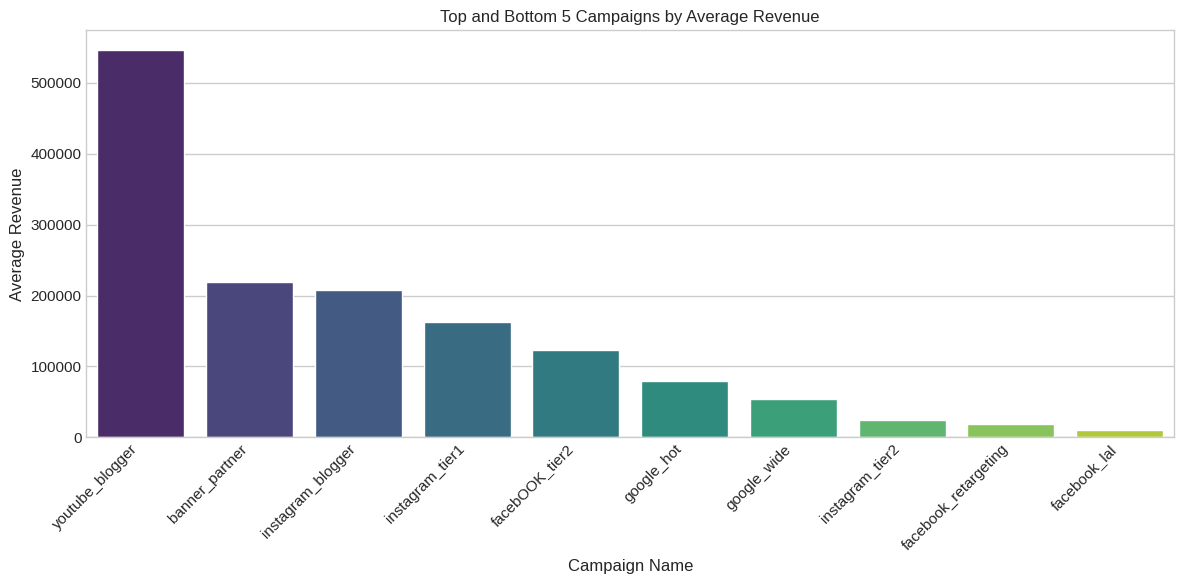

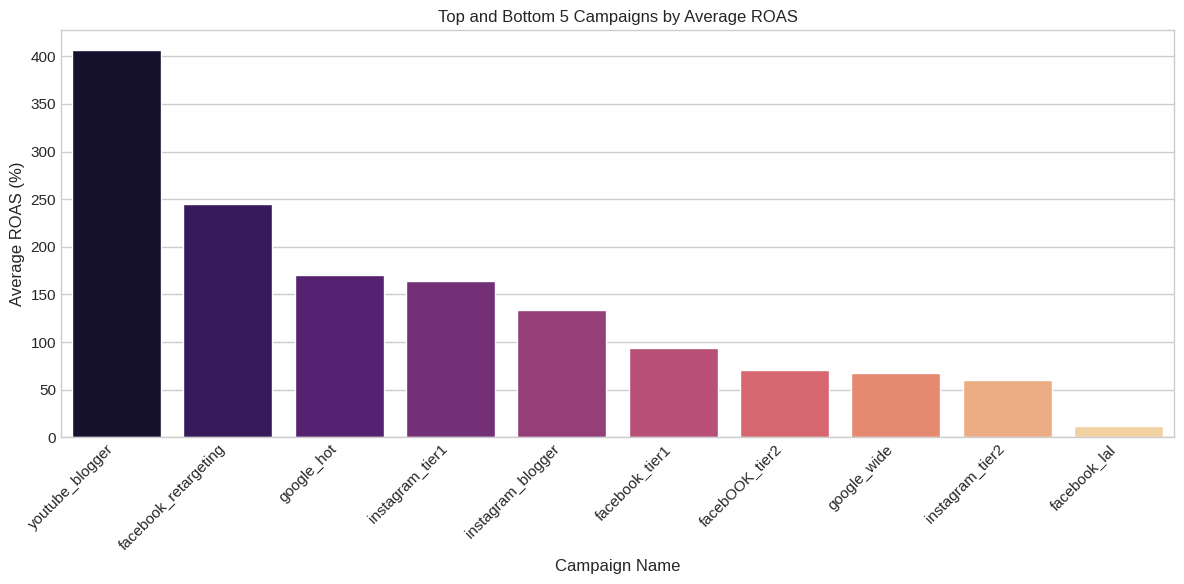

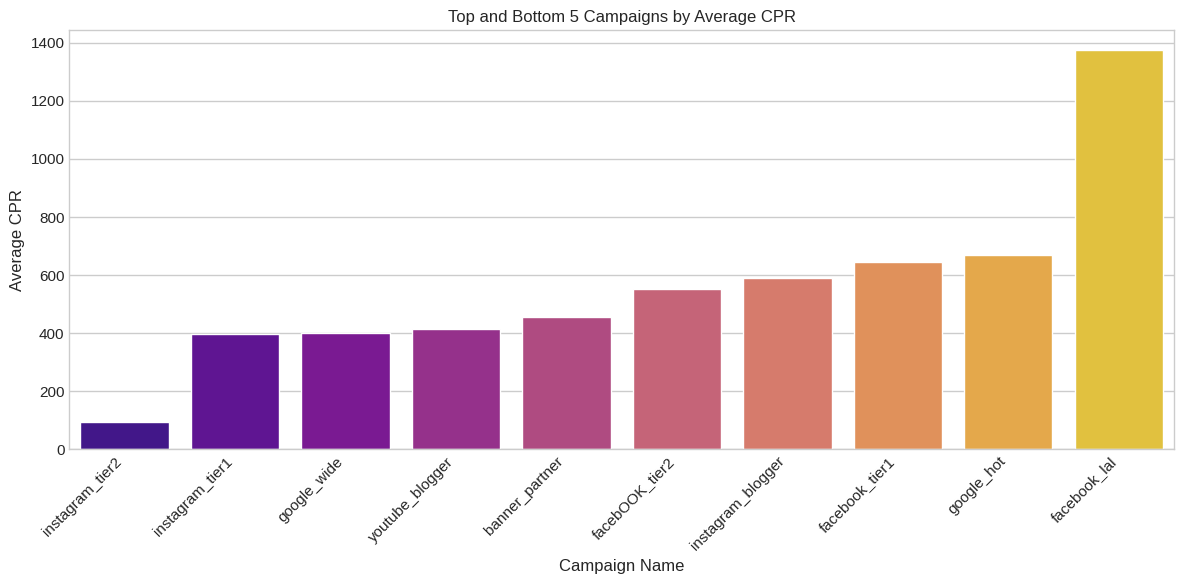

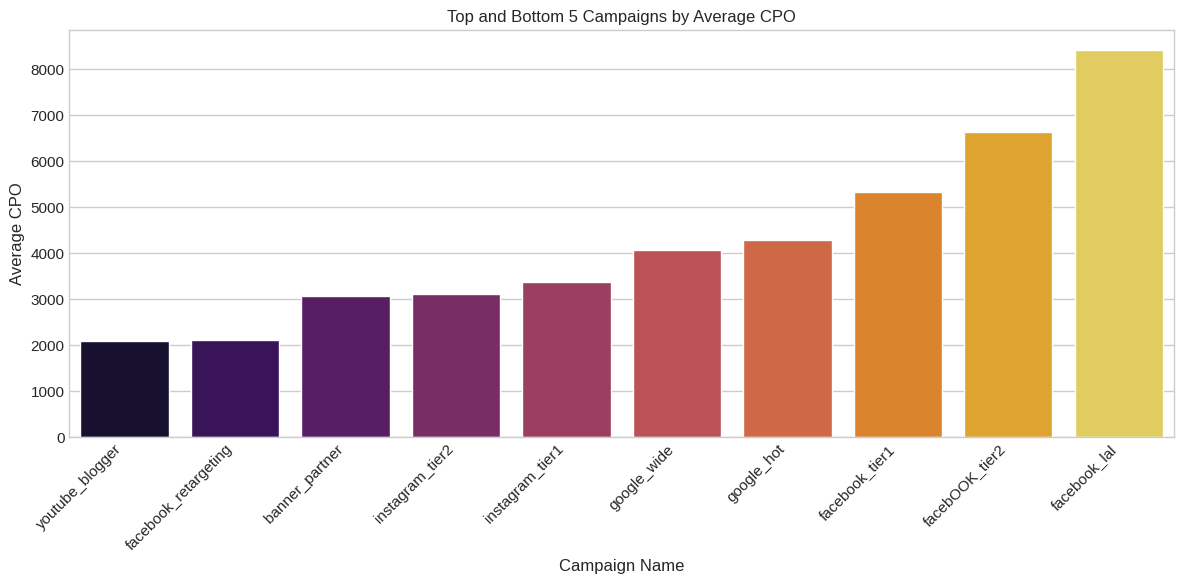

In [89]:
if not df.empty:
    print("Visualisasi Campaign Berkinerja Terbaik dan Terburuk:")

    # Pastikan kolom KPI ada
    kpi_columns = ['CTR', 'CPC', 'CPR', 'CPO', 'ROAS', 'revenue']
    if all(col in df.columns for col in kpi_columns):

        # Hitung rata-rata KPI dan revenue per campaign (jika belum ada dari sel 11)
        # Jika sel 11 sudah dieksekusi, variabel campaign_performance_by_* sudah ada
        # Jika tidak, kita hitung ulang di sini
        if 'campaign_performance_by_revenue' not in locals():
             campaign_performance = df.groupby('campaign_name')[kpi_columns].mean().reset_index()
             campaign_performance_by_revenue = campaign_performance.sort_values(by='revenue', ascending=False)
             campaign_performance_by_roas = campaign_performance.sort_values(by='ROAS', ascending=False)
             campaign_performance_by_cpr = campaign_performance.sort_values(by='CPR', ascending=True)
             campaign_performance_by_cpo = campaign_performance.sort_values(by='CPO', ascending=True)


        # Ambil top dan bottom N campaign
        n_campaigns = 5 # Jumlah campaign terbaik/terburuk yang ingin divisualisasikan

        top_revenue = campaign_performance_by_revenue.head(n_campaigns)
        bottom_revenue = campaign_performance_by_revenue.tail(n_campaigns)

        top_roas = campaign_performance_by_roas.head(n_campaigns)
        bottom_roas = campaign_performance_by_roas.tail(n_campaigns)

        # Untuk CPR dan CPO, abaikan NaN sebelum mengambil top/bottom
        top_cpr = campaign_performance_by_cpr.dropna(subset=['CPR']).head(n_campaigns)
        bottom_cpr = campaign_performance_by_cpr.dropna(subset=['CPR']).tail(n_campaigns)

        top_cpo = campaign_performance_by_cpo.dropna(subset=['CPO']).head(n_campaigns)
        bottom_cpo = campaign_performance_by_cpo.dropna(subset=['CPO']).tail(n_campaigns)


        # --- Visualisasi ---

        # Visualisasi Revenue (Top & Bottom)
        plt.figure(figsize=(12, 6))
        sns.barplot(data=pd.concat([top_revenue, bottom_revenue]), x='campaign_name', y='revenue', palette='viridis', hue='campaign_name', legend=False)
        plt.title(f'Top and Bottom {n_campaigns} Campaigns by Average Revenue')
        plt.xlabel('Campaign Name')
        plt.ylabel('Average Revenue')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # Visualisasi ROAS (Top & Bottom)
        plt.figure(figsize=(12, 6))
        sns.barplot(data=pd.concat([top_roas, bottom_roas]), x='campaign_name', y='ROAS', palette='magma', hue='campaign_name', legend=False)
        plt.title(f'Top and Bottom {n_campaigns} Campaigns by Average ROAS')
        plt.xlabel('Campaign Name')
        plt.ylabel('Average ROAS (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # Visualisasi CPR (Top & Bottom - Lowest & Highest Cost)
        plt.figure(figsize=(12, 6))
        sns.barplot(data=pd.concat([top_cpr, bottom_cpr]), x='campaign_name', y='CPR', palette='plasma', hue='campaign_name', legend=False)
        plt.title(f'Top and Bottom {n_campaigns} Campaigns by Average CPR')
        plt.xlabel('Campaign Name')
        plt.ylabel('Average CPR')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # Visualisasi CPO (Top & Bottom - Lowest & Highest Cost)
        plt.figure(figsize=(12, 6))
        sns.barplot(data=pd.concat([top_cpo, bottom_cpo]), x='campaign_name', y='CPO', palette='inferno', hue='campaign_name', legend=False)
        plt.title(f'Top and Bottom {n_campaigns} Campaigns by Average CPO')
        plt.xlabel('Campaign Name')
        plt.ylabel('Average CPO')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    else:
        missing = [col for col in kpi_columns if col not in df.columns]
        print(f"Error: Kolom KPI berikut tidak ditemukan: {missing}. Mohon eksekusi sel perhitungan KPI terlebih dahulu.")

else:
    print("DataFrame kosong, tidak dapat menampilkan visualisasi campaign terbaik dan terburuk.")

**Insight dari Visualisasi Campaign Berkinerja Terbaik dan Terburuk:**

Visualisasi di atas memberikan gambaran visual yang jelas mengenai campaign mana yang berkinerja paling baik dan paling buruk berdasarkan metrik Revenue, ROAS, CPR, dan CPO.

*   **Revenue:** Grafik pertama menunjukkan campaign dengan rata-rata pendapatan tertinggi dan terendah. Campaign di puncak adalah kontributor utama pendapatan, sementara yang di dasar perlu dievaluasi untuk memahami mengapa hasilnya rendah.
*   **ROAS:** Grafik kedua menyoroti efisiensi biaya campaign dalam menghasilkan pendapatan. Campaign dengan ROAS tinggi memberikan pengembalian investasi yang baik, sedangkan ROAS rendah menunjukkan inefisiensi.
*   **CPR:** Grafik ketiga (diurutkan dari biaya terendah) menampilkan campaign yang paling efisien (CPR rendah) dan paling mahal (CPR tinggi) dalam mendapatkan leads.
*   **CPO:** Grafik keempat (diurutkan dari biaya terendah) menunjukkan campaign yang paling efisien (CPO rendah) dan paling mahal (CPO tinggi) dalam menghasilkan pesanan/penjualan.

**Penjelasan Tambahan dan Rekomendasi:**

*   **Campaign Terbaik:** Identifikasi campaign yang secara konsisten muncul di daftar teratas untuk Revenue dan ROAS, serta daftar terbawah untuk CPR dan CPO. Campaign ini adalah aset berharga dan harus dipertimbangkan untuk peningkatan anggaran atau dijadikan studi kasus. Contoh dari visualisasi Anda mungkin termasuk campaign seperti 'youtube_blogger' (ROAS tertinggi) atau 'instagram_tier2' (CPR terendah).
*   **Campaign Terburuk:** Perhatikan campaign yang muncul di daftar terbawah untuk Revenue dan ROAS, serta daftar teratas untuk CPR dan CPO. Campaign ini memboroskan anggaran atau tidak efektif dalam menghasilkan konversi. Analisis mendalam diperlukan untuk memahami akar masalahnya (penargetan, materi iklan, kualitas leads, dll.). Campaign dengan nilai NaN pada CPR/CPO/ROAS (karena tidak ada leads/orders/revenue) adalah indikator masalah serius dalam funnel konversi.
*   **Kombinasi Metrik:** Penting untuk melihat performa secara holistik. Campaign dengan CTR tinggi belum tentu bagus jika CPO-nya juga tinggi. Campaign yang murah (CPC/CPR rendah) tidak ada artinya jika tidak menghasilkan penjualan (CPO tinggi atau Revenue rendah).
*   **Tindakan Strategis:**
    *   **Tingkatkan Investasi:** Pada campaign yang terbukti berkinerja tinggi.
    *   **Optimasi:** Campaign yang berkinerja moderat bisa dioptimasi lebih lanjut.
    *   **Investigasi/Hentikan:** Campaign yang terus menerus berkinerja buruk atau tidak menghasilkan konversi sama sekali perlu diinvestigasi mendalam atau dipertimbangkan untuk dihentikan.

Visualisasi ini menjadi dasar yang kuat untuk pengambilan keputusan strategis dalam alokasi anggaran dan optimasi campaign pemasaran.

---

## 12. 🎯 Rekomendasi KPI Optimal Berdasarkan Tujuan Bisnis

In [90]:
print("## Rekomendasi KPI Optimal Berdasarkan Tujuan Bisnis")

print("\nPenentuan KPI optimal sangat bergantung pada tujuan spesifik campaign atau bisnis secara keseluruhan.")

print("\n### Contoh Penentuan KPI Optimal berdasarkan Tujuan:")
print("- **Tujuan: Meningkatkan Brand Awareness & Traffic Website:**")
print("  - KPI Utama: **CTR (Click-Through Rate)** dan **CPC (Cost Per Click)**.")
print("  - Fokus: Menciptakan iklan yang menarik (CTR tinggi) dan mendapatkan klik dengan biaya seefisien mungkin (CPC rendah).")

print("\n- **Tujuan: Menghasilkan Leads Berkualitas:**")
print("  - KPI Utama: **CPR (Cost Per Lead)** dan **Tingkat Konversi Leads menjadi Sales (Lead-to-Sales Conversion Rate)**.")
print("  - Fokus: Mendapatkan leads dengan biaya serendah mungkin (CPR rendah) DAN memastikan leads tersebut berkualitas (tingkat konversi ke sales tinggi). Analisis kualitas leads penting di sini.")

print("\n- **Tujuan: Meningkatkan Penjualan & Profitabilitas:**")
print("  - KPI Utama: **ROAS (Return on Ad Spend)**, **Revenue**, dan **CPO (Cost Per Order)**.")
print("  - Fokus: Memaksimalkan pengembalian investasi iklan (ROAS tinggi), meningkatkan total revenue, dan mendapatkan pesanan dengan biaya seefisien mungkin (CPO rendah). Profitabilitas (Revenue - Mark Spent) juga bisa menjadi metrik kunci.")

print("\n### Pertimbangan Penting:")
print("- **Kualitas vs Kuantitas:** Jangan hanya fokus pada kuantitas (misal, leads banyak dengan CPR rendah) tanpa mempertimbangkan kualitasnya (apakah leads tersebut berubah menjadi pelanggan?).")
print("- **Holistik:** Lihat KPI secara holistik, bukan terpisah. CPC rendah tidak ada artinya jika CTR juga rendah atau konversi setelah klik buruk.")
print("- **Benchmark:** Tetapkan target KPI yang realistis berdasarkan data historis (seperti analisis per kategori/campaign di atas) dan standar industri.")
print("- **Dinamis:** Tinjau dan sesuaikan KPI secara berkala seiring perubahan tujuan bisnis dan kondisi pasar.")

print("\n**Rekomendasi:**")
print("Identifikasi tujuan utama setiap campaign atau kelompok campaign, lalu prioritaskan KPI yang paling relevan untuk tujuan tersebut. Gunakan KPI lain sebagai metrik pendukung untuk memahami efisiensi di setiap tahap funnel.")

## Rekomendasi KPI Optimal Berdasarkan Tujuan Bisnis

Penentuan KPI optimal sangat bergantung pada tujuan spesifik campaign atau bisnis secara keseluruhan.

### Contoh Penentuan KPI Optimal berdasarkan Tujuan:
- **Tujuan: Meningkatkan Brand Awareness & Traffic Website:**
  - KPI Utama: **CTR (Click-Through Rate)** dan **CPC (Cost Per Click)**.
  - Fokus: Menciptakan iklan yang menarik (CTR tinggi) dan mendapatkan klik dengan biaya seefisien mungkin (CPC rendah).

- **Tujuan: Menghasilkan Leads Berkualitas:**
  - KPI Utama: **CPR (Cost Per Lead)** dan **Tingkat Konversi Leads menjadi Sales (Lead-to-Sales Conversion Rate)**.
  - Fokus: Mendapatkan leads dengan biaya serendah mungkin (CPR rendah) DAN memastikan leads tersebut berkualitas (tingkat konversi ke sales tinggi). Analisis kualitas leads penting di sini.

- **Tujuan: Meningkatkan Penjualan & Profitabilitas:**
  - KPI Utama: **ROAS (Return on Ad Spend)**, **Revenue**, dan **CPO (Cost Per Order)**.
  - Fokus: Memaksimalkan pengemba

**Insight dari Rekomendasi KPI Optimal:**
- Tidak ada satu set KPI yang 'optimal' untuk semua situasi. Definisi 'optimal' sangat bergantung pada apa yang ingin dicapai oleh campaign atau bisnis.
- Memahami hubungan antar KPI dan bagaimana masing-masing berkontribusi pada tujuan akhir sangat penting untuk pengambilan keputusan yang tepat.
- **Rekomendasi:** Komunikasikan tujuan bisnis dengan jelas sebelum merancang campaign dan menetapkan KPI. Gunakan analisis data (seperti yang dilakukan di notebook ini) untuk menginformasikan target KPI yang realistis dan mengukur keberhasilan secara akurat.

---

## 13. 📄 Ringkasan Temuan Kunci dan Rekomendasi Strategis Keseluruhan

In [91]:
print("## Ringkasan Temuan Kunci dan Rekomendasi Strategis Keseluruhan")

print("\n### Ringkasan Temuan Kunci:")
print("- **Distribusi Data:** Sebagian besar metrik pemasaran menunjukkan distribusi yang miring ke kanan, mengindikasikan adanya campaign atau periode waktu dengan performa/pengeluaran yang jauh di atas rata-rata.")
print("- **Korelasi KPI-Revenue:** Korelasi antara KPI (CTR, CPC, CPR) dan Revenue tergolong lemah, menunjukkan bahwa Revenue dipengaruhi oleh kombinasi faktor dan kualitas konversi di seluruh funnel.")
print("- **Performa per Kategori:** Kategori 'influencer' dan 'media' menonjol dalam hal rata-rata Revenue dan/atau efisiensi biaya (CPR, ROAS). Kategori 'search' unggul di CTR.")
print("- **Tren Harian:** Performa harian menunjukkan fluktuasi yang signifikan tanpa tren jangka panjang yang jelas dalam periode data ini.")
print("- **Campaign Berkinerja:** Campaign 'youtube_blogger' memimpin Revenue. Campaign 'instagram_tier2', 'instagram_tier1', 'google_wide' paling efisien dalam Cost Per Lead. Campaign dengan CPR/CPO/ROAS buruk atau NaN memerlukan investigasi serius.")
print("- **KPI Optimal:** Pemilihan KPI kunci harus selaras dengan tujuan bisnis (awareness, leads, sales).")

print("\n### Rekomendasi Strategis Utama:")
print("- **Alokasi Anggaran Berbasis Data:** Tingkatkan investasi pada campaign dan kategori yang terbukti menghasilkan Revenue tinggi dan/atau efisiensi biaya yang baik (ROAS tinggi, CPR/CPO rendah).")
print("- **Optimasi Funnel Konversi:** Untuk campaign dengan CTR tinggi namun konversi rendah (leads/sales), fokus pada perbaikan landing page, penawaran, dan alur konversi.")
print("- **Investigasi Campaign Berkinerja Buruk:** Lakukan audit mendalam pada campaign dengan metrik konversi yang buruk atau NaN. Identifikasi akar masalah (penargetan, kreatif, relevansi) dan ambil tindakan korektif atau penghentian.")
print("- **Manfaatkan Keunggulan Kategori:** Pelajari dan replikasikan strategi sukses dari kategori 'influencer' dan 'media'.")
print("- **Monitoring Aktif:** Pantau performa harian/mingguan untuk respons cepat terhadap perubahan.")
print("- **Definisikan & Ukur KPI yang Tepat:** Pastikan KPI yang dipantau relevan dengan tujuan spesifik setiap inisiatif pemasaran.")
print("- **Analisis Profitabilitas:** Selain Revenue, selalu pertimbangkan Cost Per Order (CPO) dan ROAS untuk memahami profitabilitas campaign penjualan.")

## Ringkasan Temuan Kunci dan Rekomendasi Strategis Keseluruhan

### Ringkasan Temuan Kunci:
- **Distribusi Data:** Sebagian besar metrik pemasaran menunjukkan distribusi yang miring ke kanan, mengindikasikan adanya campaign atau periode waktu dengan performa/pengeluaran yang jauh di atas rata-rata.
- **Korelasi KPI-Revenue:** Korelasi antara KPI (CTR, CPC, CPR) dan Revenue tergolong lemah, menunjukkan bahwa Revenue dipengaruhi oleh kombinasi faktor dan kualitas konversi di seluruh funnel.
- **Performa per Kategori:** Kategori 'influencer' dan 'media' menonjol dalam hal rata-rata Revenue dan/atau efisiensi biaya (CPR, ROAS). Kategori 'search' unggul di CTR.
- **Tren Harian:** Performa harian menunjukkan fluktuasi yang signifikan tanpa tren jangka panjang yang jelas dalam periode data ini.
- **Campaign Berkinerja:** Campaign 'youtube_blogger' memimpin Revenue. Campaign 'instagram_tier2', 'instagram_tier1', 'google_wide' paling efisien dalam Cost Per Lead. Campaign dengan CPR/CPO/ROAS bu

---

## 14. ✅ Finish Task

Analisis kinerja pemasaran telah selesai. Notebook ini menyediakan gambaran lengkap dari data, metrik kunci, insight, dan rekomendasi untuk optimasi.

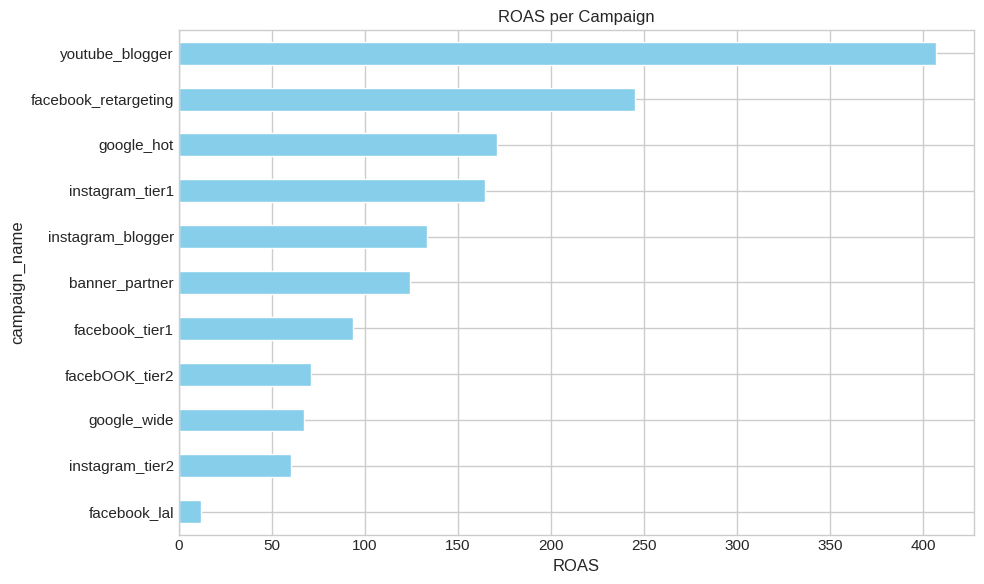

In [92]:
import matplotlib.pyplot as plt

df.groupby('campaign_name')['ROAS'].mean().sort_values().plot(
    kind='barh', figsize=(10,6), color='skyblue', title='ROAS per Campaign')
plt.xlabel('ROAS')
plt.tight_layout()
plt.show()



In [93]:
df.to_csv('evaluasi_kpi_campaign.csv', index=False)